# **BUSINESS UNDERSTANDING**

This project aims to analyze customer behavior and segment customers based on their value using RFM (Recency, Frequency, Monetary) analysis.

The objective is to:
- Identify high-value customers  
- Understand revenue distribution across customer segments  
- Support targeted retention strategies to improve business performance

# **SETUP**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


# **LOAD DATA**

In [ ]:
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **DATA CLEANING**

In [ ]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# **COHORT ANALYSIS**

In [42]:
from operator import attrgetter

# pastikan datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# convert ke monthly period
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# buat cohort table (FIRST PURCHASE MONTH)
cohort = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()

# convert ke period
cohort['CohortMonth'] = cohort['InvoiceDate'].dt.to_period('M')

# merge ke df
df = df.merge(cohort[['CustomerID', 'CohortMonth']], on='CustomerID', how='left')

# cohort index
df['CohortIndex'] = (df['YearMonth'] - df['CohortMonth']).apply(attrgetter('n'))

# **BUSINESS OVERVIEW**

In [ ]:
print("Total Transactions:", df.shape[0])
print("Total Customers:", df['CustomerID'].nunique())
print("Total Revenue:", df['Revenue'].sum())

Total Transactions: 397884
Total Customers: 4338
Total Revenue: 8911407.904


# **RFM Analysis**

In [ ]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# **RFM Scoring**

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# **Segmentation**

In [ ]:
rfm['Segment'] = pd.qcut(rfm['Monetary'], 3, labels=['Low Value', 'Mid Value', 'High Value'])

# **Business Metrics**

In [ ]:
customer_pct = rfm['Segment'].value_counts(normalize=True) * 100
revenue_pct = rfm.groupby('Segment')['Monetary'].sum() / rfm['Monetary'].sum() * 100
low_value_count = rfm['Segment'].value_counts()['Low Value']

/tmp/ipykernel_2922/2580896565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_pct = rfm.groupby('Segment')['Monetary'].sum() / rfm['Monetary'].sum() * 100


# **Visualization**

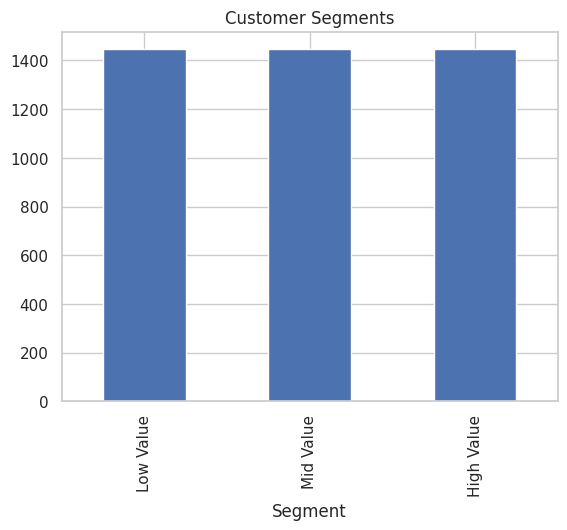

In [ ]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

# **Business Questions**

1. Customers High Value?

In [ ]:
customer_pct['High Value']

np.float64(33.33333333333333)

2. Revenue dari High Value?

In [ ]:
revenue_pct['High Value']

np.float64(84.85772239878833)

3. Low Value customers?

In [ ]:
rfm['Segment'].value_counts()['Low Value']

np.int64(1446)

# **BUSINESS INSIGHT**

1. High Value customers represent approximately 33.3% of the total customer base but contribute around 84.9% of total revenue.
2. This indicates a strong revenue concentration where a relatively small segment of customers drives the majority of business value.
3. Low Value customers account for a large portion of the customer base (1,446 customers), but contribute significantly less to total revenue.


## **Cohort Visualization**

In [43]:
cohort_pivot = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_pivot = cohort_pivot.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

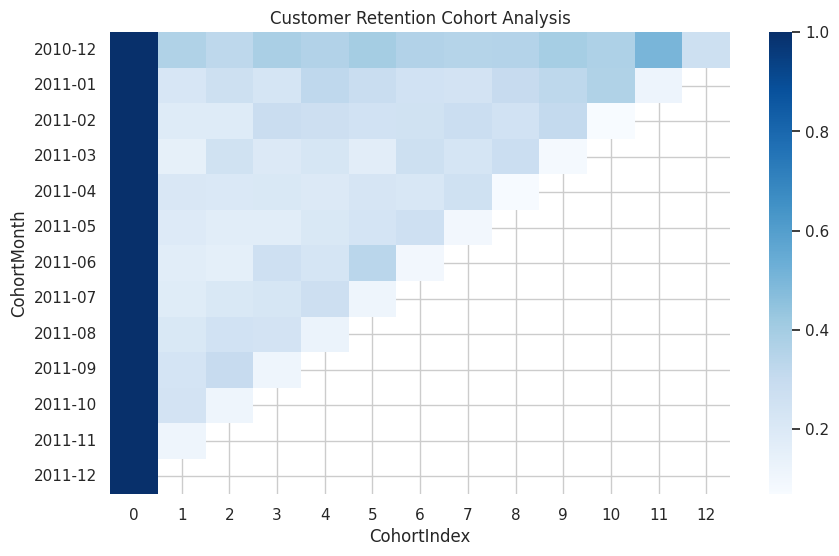

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=False, cmap="Blues")
plt.title("Customer Retention Cohort Analysis")
plt.show()

# **BUSINESS RECOMMENDATIONS**

1. Prioritize retention strategies for High Value customers to protect majority revenue contribution.
2. Design loyalty and upsell programs to further increase lifetime value of High Value segment.
3. Develop engagement strategies for Mid Value customers to move them into High Value segment.
4. Run cost-efficient reactivation campaigns for Low Value customers, focusing only on those with potential upsell behavior.

# **PEOPENSITY MODEL (CUSTOMER VALUE PREDICTION)**

# **CREATE TARGET LABEL**

In [ ]:
rfm['target'] = np.where(rfm['Segment'] == 'High Value', 1, 0)

# **FEATURES**

In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['target']

# **TRAIN TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **LOGISTIC REGRESSION MODEL**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# **EVALUATION**

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       580
           1       1.00      1.00      1.00       288

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       580
           1       1.00      1.00      1.00       288

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



# **MODEL INTERPRETATION**

The logistic regression model achieved perfect performance on the test set, with an accuracy of 1.00 and consistently perfect precision, recall, and F1-scores for both classes (High Value vs Non-High Value customers).

This indicates that the model was able to correctly classify all test samples without any errors. In business terms, the model can clearly distinguish between high-value customers and other customer segments based on RFM features (Recency, Frequency, Monetary).

However, such perfect results may also suggest a possibility of data leakage or overly separable classes, so further validation (e.g., cross-validation or feature review) is recommended to ensure the model’s generalization on unseen data.

# **BUSINESS KPI LAYER**

In [45]:
total_customers = df['CustomerID'].nunique()
total_revenue = df['Revenue'].sum()

high_value_share = (rfm['Segment'] == 'High Value').mean() * 100
high_value_revenue_share = rfm[rfm['Segment']=='High Value']['Monetary'].sum() / rfm['Monetary'].sum() * 100

# **DECISION SYSTEM**

In [46]:
rfm['prob_high_value'] = model.predict_proba(X)[:,1]

In [47]:
rfm['action'] = rfm['prob_high_value'].apply(
    lambda x: "Retention" if x > 0.7 else "Upsell" if x > 0.4 else "Reactivate"
)

# **SQL Equivalent Thinking**

```sql
-- Total revenue per customer
SELECT CustomerID,
       SUM(Quantity * UnitPrice) AS Revenue
FROM online_retail
GROUP BY CustomerID;

-- Customer revenue ranking (business prioritization)
SELECT
    CustomerID,
    SUM(Quantity * UnitPrice) AS Revenue,
    RANK() OVER (ORDER BY SUM(Quantity * UnitPrice) DESC) AS revenue_rank
FROM online_retail
GROUP BY CustomerID;

-- Customer segmentation logic (quantile-style in SQL)
SELECT *,
       NTILE(3) OVER (ORDER BY Revenue DESC) AS revenue_segment
FROM (
    SELECT CustomerID,
           SUM(Quantity * UnitPrice) AS Revenue
    FROM online_retail
    GROUP BY CustomerID
) t;
```

# **FEATURE INSIGHT**

In [ ]:
model.coef_

array([[0.07316519, 0.06592325, 1.24130113]])

# **INTERPRETATION**

The model coefficients indicate the impact of each feature on predicting high-value customers:

1. Recency (0.073): Slight positive impact, meaning more recent activity slightly increases the likelihood of being a high-value customer.
2. Frequency (0.066): Small positive impact, indicating that customers who purchase more frequently are more likely to be high-value.
3. Monetary (1.241): Strong positive impact, meaning total spending is the most important factor in identifying high-value customers.

# **EXECUTIVE SUMMARY**

This analysis identifies customer value patterns using RFM segmentation, cohort retention analysis, and predictive modeling. High-value customers contribute a disproportionate share of revenue, while retention patterns show early churn risk among new customers. A logistic regression model enables early identification of valuable customers, allowing targeted retention, upselling, and reactivation strategies to improve overall business efficiency and revenue optimization.